In [ ]:
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [20]:
import torch

from image_utils import ImageUtils
from dino_detector import DinoDetector
from clip_classifier import ClipClassifier

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GROUNDING_PROMPT = (
    "food, meal, cooked food, dish, plate, bowl, wooden plate, ceramic plate"
)
FOOD_PROMPTS = ["food", "meal", "cooked food"]
CONTAINER_PROMPTS = ["plate", "bowl", "dish", "wooden plate", "ceramic plate"]

BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.25

# sam
SAM_CHECKPOINT = "checkpoints/sam_vit_b_01ec64.pth"
SAM_MODEL_TYPE = "vit_b"

In [ ]:
from loaders import load_openclip, load_grounding_dino, load_sam

# load checkpoints
clip_model, preprocess, tokenizer = load_openclip(device=DEVICE)
dino_model = load_grounding_dino()
sam_predictor = load_sam(SAM_CHECKPOINT, SAM_MODEL_TYPE, device=DEVICE)

# create objects
dino_detector = DinoDetector(
    device=DEVICE,
    model=dino_model
)

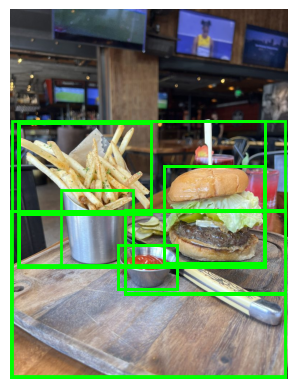

In [21]:
# image
image_path = "photos/wood_dish_1.png"
# image_path = "photos/out_screen1.png"
# image_path = "photos/ok_light_2.png"
# image_path = "photos/bad_light_1.png"
# image_path = "photos/good_light_1.png"

# detect objects
image_source, image, boxes = dino_detector.detect_boxes(
    image_path,
    grounding_prompt=GROUNDING_PROMPT,
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
)

ImageUtils.display_bounding_boxes(image_source, boxes)

In [22]:
from core.models import RegionPrompt
from image_utils import ImageUtils

pil_img = ImageUtils.convert_img_source_to_pil(image_source)

clip_classifier = ClipClassifier(
    clip_model,
    preprocess=preprocess,
    tokenizer=tokenizer,
    device=DEVICE,
)

kept = []
regions: list[RegionPrompt] = []

for box in boxes:
    crop = pil_img.crop(box)
    label = clip_classifier.classify_dish_items(
        crop=crop,
        food_prompts=FOOD_PROMPTS,
        container_prompts=CONTAINER_PROMPTS,
        threshold=0.30
    )

    if label:
        region = RegionPrompt(box=box, label=label)
        regions.append(region)

In [ ]:
from sam_segmenter import SamSegmenter

sam_segmenter = SamSegmenter(predictor=sam_predictor, device=DEVICE)
regions_with_masks = sam_segmenter.segment(image=ImageUtils.pil_to_numpy(pil_img), regions=regions)

ImageUtils.display_regions_with_masks(regions_with_masks)

In [ ]:
foods, plates = [], []
for item, mask in zip(kept, masks):
    if item["label"] == "food":
        foods.append({"box": item["box"], "mask": mask})
    else:
        plates.append({"box": item["box"], "mask": mask})

# display food and labels
for f in foods:
    plt.imshow(f["mask"])
    plt.title("food")
    plt.show()
#
for plate in plates:
    plt.imshow(plate["mask"])
    plt.title("plate")
    plt.show()